# Notebook 03: Banking Exploratory Data Analysis (EDA)

## Project: Enterprise Credit Risk Modelling & Independent Model Validation (SR 11-7)

In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

root_path = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
src_path = root_path / "src"
for p in [str(root_path), str(src_path)]:
    if p not in sys.path:
        sys.path.insert(0, p)

sns.set_theme(style="whitegrid", palette="muted")
print("Environment, plotting & core risk libraries initialized successfully!")

Environment, plotting & core risk libraries initialized successfully!


In [2]:
data_file = root_path / "data" / "processed" / "accepted_2007_to_2018Q4_feature_engineered.csv.gz"
if data_file.is_file():
    df = pd.read_csv(data_file, nrows=50000, low_memory=False)
    bad = ["Charged Off", "Default", "Does not meet the credit policy. Status:Charged Off", "Late (31-120 days)"]
    good = ["Fully Paid", "Does not meet the credit policy. Status:Fully Paid"]
    df["target"] = np.nan
    df.loc[df["loan_status"].isin(bad), "target"] = 1.0
    df.loc[df["loan_status"].isin(good), "target"] = 0.0
    df = df.dropna(subset=["target"]).copy()
    df["target"] = df["target"].astype(int)
    num_cols = ["loan_amnt", "int_rate", "installment", "annual_inc", "dti", "fico_range_low", "revol_util"]
    for c in num_cols:
        if c in df.columns:
            df[c] = df[c].fillna(df[c].median())
else:
    df = mock_df.copy()

print(f"Dataset Loaded: {len(df):,} loans | Default Rate: {df['target'].mean():.4%}")

Dataset Loaded: 44,252 loans | Default Rate: 20.9572%


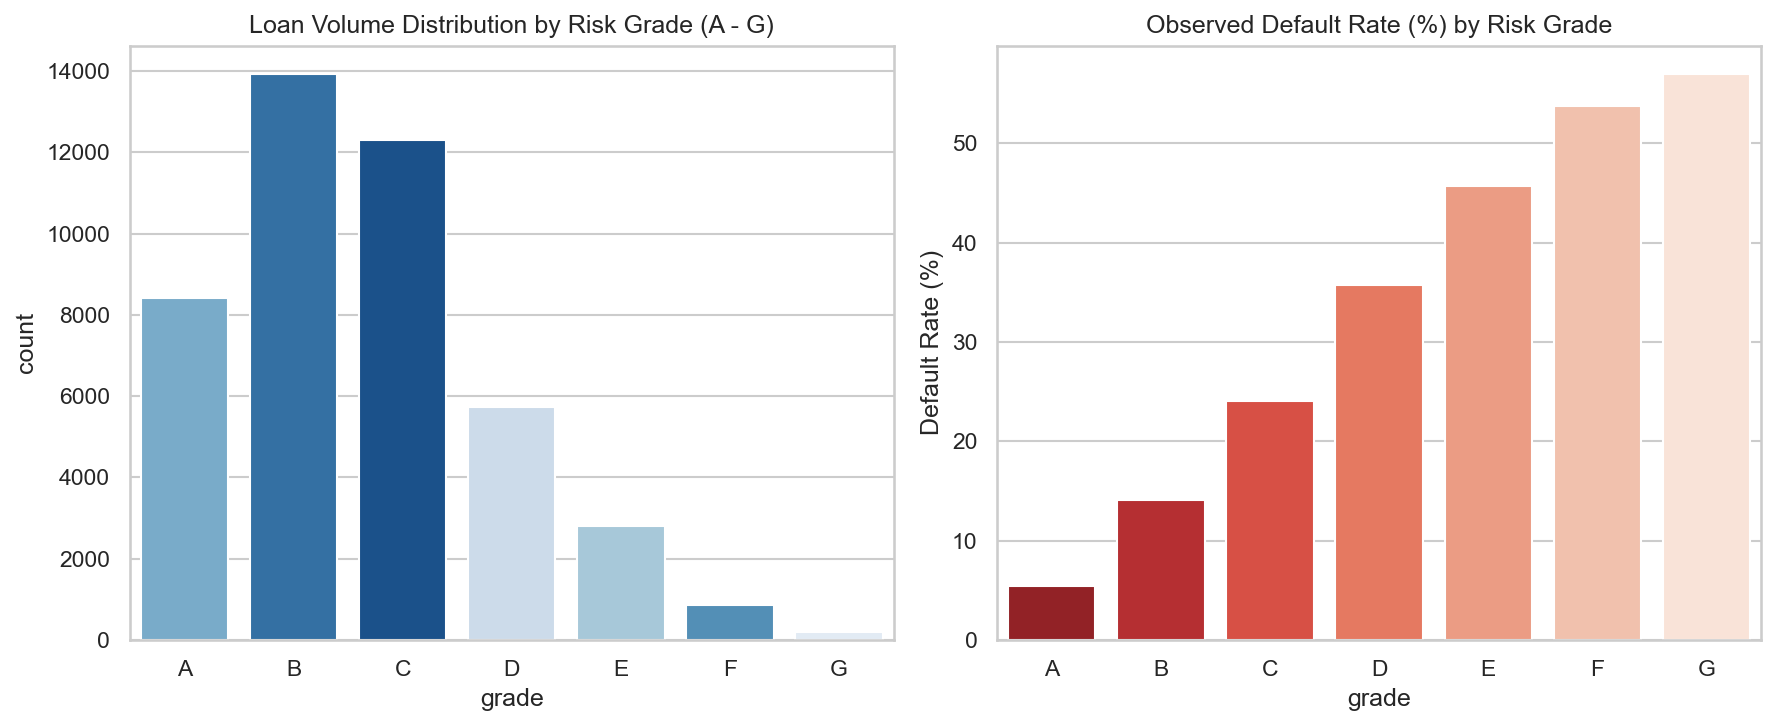

In [3]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=df, x="grade", hue="grade", order=sorted(df["grade"].unique()), palette="Blues_r", legend=False)
plt.title("Loan Volume Distribution by Risk Grade (A - G)")
plt.subplot(1, 2, 2)
grade_def = df.groupby("grade", observed=False)["target"].mean() * 100
sns.barplot(x=grade_def.index, y=grade_def.values, hue=grade_def.index, palette="Reds_r", legend=False)
plt.title("Observed Default Rate (%) by Risk Grade")
plt.ylabel("Default Rate (%)")
plt.tight_layout()
plt.show()

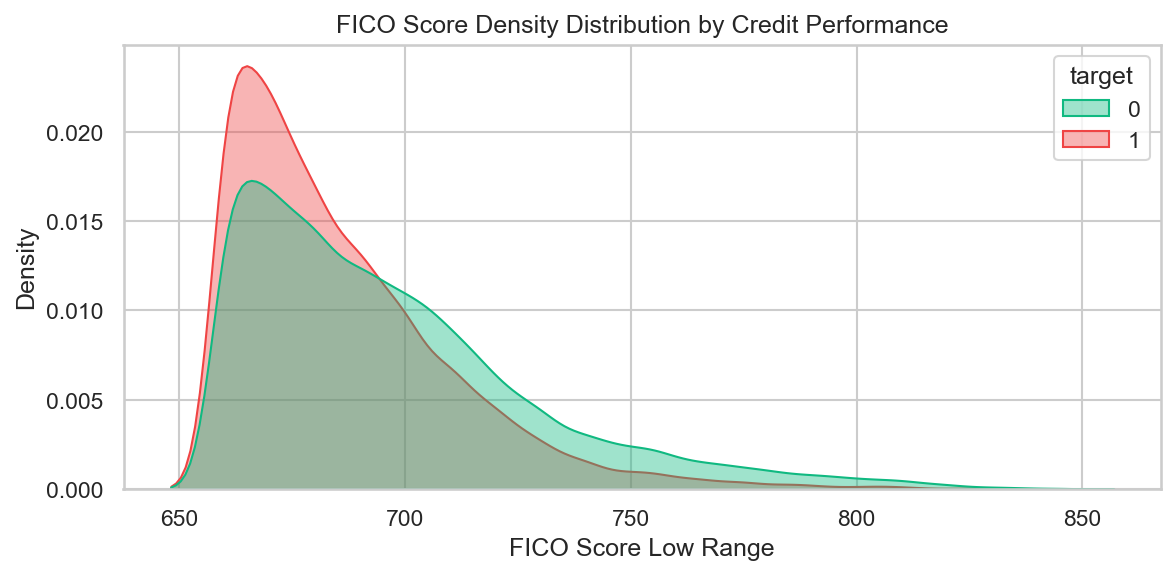

In [4]:
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x="fico_range_low", hue="target", common_norm=False, palette=["#10B981", "#EF4444"], fill=True, alpha=0.4)
plt.title("FICO Score Density Distribution by Credit Performance")
plt.xlabel("FICO Score Low Range")
plt.tight_layout()
plt.show()